In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from functools import partial
from ciceroscm import input_handler

from meteor import MeteorPatternScaling
from meteor import prpatt
from meteor import Cmip6MeteorDataGetter


In [17]:
cscm_data_dir = "../src/meteor/default_scm_data"


In [18]:
data_getter = Cmip6MeteorDataGetter(exps=["piControl", "abrupt-4xCO2", "historical", "ssp245"], dbe=['CMIP','CMIP','CMIP', 'ScenarioMIP'])
models = data_getter.models
models = ["CanESM5", "NorESM2-LM"]
flds = ["tas", "pr"]

#For predictions: 
conc_data = input_handler.read_inputfile(
    os.path.join(cscm_data_dir, "ssp245_conc_RCMIP.txt")
)
ih = input_handler.InputHandler({})
em_data = ih.read_emissions(os.path.join(cscm_data_dir, "ssp245_em_RCMIP.txt"))

/Users/sanderson/code/METEOR/venv/lib/python3.9/site-packages/ciceroscm/input_handler.py:98: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_input = pd.read_csv(
Parameter nystart not in pamset. Using default value 1750
Parameter nyend not in pamset. Using default value 2100
Parameter emstart not in pamset. Using default value 1850
/Users/sanderson/code/METEOR/venv/lib/python3.9/site-packages/ciceroscm/input_handler.py:98: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_input = pd.read_csv(


In [5]:
models

['CanESM5', 'NorESM2-LM']

In [6]:
train_data=data_getter.make_meteor_training_data

In [7]:
model_basic_pattern = [None] * len(models)
pattern_ssp=[None] * len(models)
for i, model in enumerate(models):
    # Build pattern 
    model_basic_pattern[i] = MeteorPatternScaling(
        f"cmip6-{model}-basic",
        {"tas": 2, "pr": 10},
        partial(train_data, model=model),
        from_file=False,
        exp_list=["base", "co2x4"],
        )
    print(model_basic_pattern[i].exp_forc_dict)
    #sys.exit(4)
    # Predict for ssp
    pattern_ssp[i] = model_basic_pattern[i].predict_from_combined_experiment(
        em_data, conc_data, ["pr", "tas"]
        )


Parameter nystart not in pamset. Using default value 1750
Parameter nyend not in pamset. Using default value 2100
Parameter emstart not in pamset. Using default value 1850
/Users/sanderson/code/METEOR/venv/lib/python3.9/site-packages/ciceroscm/input_handler.py:98: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_input = pd.read_csv(
/Users/sanderson/code/METEOR/venv/lib/python3.9/site-packages/ciceroscm/input_handler.py:98: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_input = pd.read_csv(
/Users/sanderson/code/METEOR/venv/lib/python3.9/site-packages/ciceroscm/input_handler.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_gas = pd.read_csv(filename, delim_whitespace=True, index_col=0)
/U

Parameter beta_f not in pamset. Using default value 0.287


11
12
113
114
115
22
141
123
142


Parameter lifetime_mode is not used. Please check if you have a typo
Parameter conc_run is not used. Please check if you have a typo
Parameter lifetime_mode is not used. Please check if you have a typo
Parameter conc_run is not used. Please check if you have a typo
Parameter qbmb not in pamset. Using default value 0.0
Parameter qo3 not in pamset. Using default value 0.5
Parameter qdirso2 not in pamset. Using default value -0.36
Parameter qindso2 not in pamset. Using default value -0.97
Parameter qbc not in pamset. Using default value 0.16
Parameter qoc not in pamset. Using default value -0.08
Parameter qh2o_ch4 not in pamset. Using default value 0.091915
Parameter ref_yr not in pamset. Using default value 2010
Parameter beta_f not in pamset. Using default value 0.287


11
12
113
114
115
22
141
123
142


...

11
12
113
114
115
22
141
123
142


Parameter qbc not in pamset. Using default value 0.16
Parameter qoc not in pamset. Using default value -0.08
Parameter qh2o_ch4 not in pamset. Using default value 0.091915
Parameter ref_yr not in pamset. Using default value 2010
Parameter beta_f not in pamset. Using default value 0.287
/Users/sanderson/code/METEOR/venv/lib/python3.9/site-packages/ciceroscm/input_handler.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_gas = pd.read_csv(filename, delim_whitespace=True, index_col=0)
Parameter nystart must be a number. Using default value 1750
Parameter emstart must be a number. Using default value 1850
Parameter gaspam_data is not used. Please check if you have a typo
Parameter concentrations_data is not used. Please check if you have a typo
Parameter emissions_data is not used. Please check if you have a typo
Parameter nat_ch4_data is not used. Please check if you have a typo
Paramet

{'base': 0.0, 'co2x4': 8.534700743147258}
11
12
113
114
115
22
141
123
142


Parameter nat_ch4_data is not used. Please check if you have a typo
Parameter nat_n2o_data is not used. Please check if you have a typo
Parameter conc_run is not used. Please check if you have a typo
Parameter qbmb not in pamset. Using default value 0.0
Parameter qo3 not in pamset. Using default value 0.5
Parameter qdirso2 not in pamset. Using default value -0.36
Parameter qindso2 not in pamset. Using default value -0.97
Parameter qbc not in pamset. Using default value 0.16
Parameter qoc not in pamset. Using default value -0.08
Parameter qh2o_ch4 not in pamset. Using default value 0.091915
Parameter ref_yr not in pamset. Using default value 2010
Parameter beta_f not in pamset. Using default value 0.287


CO2
incomp
CH4
N2O
SO2
inaer
CFC-11
CFC-12
CFC-113
CFC-114
CFC-115
CH3Br
CCl4
CH3CCl3
HCFC-22
HCFC-141b
HCFC-123
HCFC-142b
H-1211
H-1301
H-2402
HFC125
HFC134a
HFC143a
HFC227ea
HFC23
HFC245fa
HFC32
HFC4310mee
C2F6
C6F14
CF4
SF6
NOx
CO
NMVOC
NH3
SO4_IND
inaer
TROP_O3
STRAT_O3
STRAT_H2O
BMB_AEROS_BC
inaer
BMB_AEROS_OC
inaer
BMB_AEROS
LANDUSE
BC
inaer
OC
inaer
OTHER
Total_forcing


In [8]:
data_pi=[None]*len(models)
for i, model in enumerate(models):
    tmp_pi=[None]*len(flds)
    for j, fld in enumerate(flds):
        tmp_pi[j]=data_getter.get_single_var_mod_data_yearmean("piControl", fld, model)
    data_pi[i]=xr.merge(tmp_pi)


In [9]:
data_hist=[None]*len(models)
for i, model in enumerate(models):
    tmp_hist=[None]*len(flds)
    for j, fld in enumerate(flds):
        tmp_hist[j]=data_getter.get_single_var_mod_data_yearmean("historical", fld, model)
    data_hist[i]=xr.merge(tmp_hist)

In [10]:
data_ssp=[None]*len(models)
for i, model in enumerate(models):
    tmp_ssp=[None]*len(flds)
    for j, fld in enumerate(flds):
        tmp_ssp[j]=data_getter.get_single_var_mod_data_yearmean("ssp245", fld, model)
    data_ssp[i]=xr.merge(tmp_ssp)

In [11]:
years_total = np.arange(1750, 2101)
years_hist = np.arange(1850, 2015)
years_ssp = np.arange(2015, 2101)

286.43933793468534
CanESM5
3.293210337026687e-05
CanESM5


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


287.62321130221943
NorESM2-LM
3.312388637578097e-05
NorESM2-LM


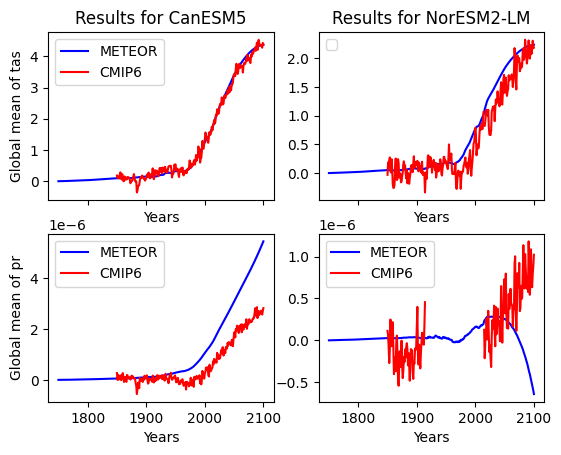

In [12]:
fig, axs = plt.subplots(nrows=len(flds), ncols=len(models), sharex=True)

for i, model in enumerate(models):
    for j, fld in enumerate(flds):
        zero_val = np.mean(prpatt.global_mean(data_pi[i][fld]).values)
        print(zero_val)
        hist_time = prpatt.global_mean(data_hist[i][fld]).values[0]
        #print(f"Variable: {fld} and model {model}: {hist_time}")
        axs[j,i].plot(years_total, prpatt.global_mean(pattern_ssp[i][fld]).values, color="blue", label="METEOR")
        print(model)
        axs[j,i].plot(years_hist[:len(hist_time)], hist_time - zero_val, color="red", label="CMIP6")
        axs[j,i].plot(years_ssp, prpatt.global_mean(data_ssp[i][fld]).values[0] - zero_val, color="red")
        #axs[j,i].set_xlim(left=1850, right=2100)
        axs[j,i].set_xlabel("Years")
        if j == 0:
            axs[j,i].set_title(f"Results for {model}")
        if i == 0:
            axs[j,i].set_ylabel(f"Global mean of {fld}")
        axs[i,j].legend()
    #print(model_basic_pattern.exp_forc_dict)